# **PHASE 4: MODELING**

**What the brief asks for:** one probability or correlation quantity that uses columns from **more than one original source**. No ML.

**My question:** do countries that spend more on education, relative to their income, have higher enrolment and lower dropout?

**What I will calculate**

| Step | Quantity | Why |
|---|---|---|
| 1 | Scatter plots | See the shape before trusting a number |
| 2 | Pearson and Spearman correlation of spending (% of GDP) with each outcome | the basic answer, for primary, secondary, tertiary and dropout |
| 3 | **Partial correlation**, controlling for log GDP per capita | richer countries spend and enrol more; this asks whether spending matters *beyond* wealth |
| 4 | Correlation inside each income group | does the pattern hold among similar-income countries? |
| 5 | **Conditional probability** P(high primary enrolment given high spending) against P(... given low spending) | an answer anyone can read |
| 6 | Robustness: country averages and a bootstrap that resamples whole countries | the same country appears in many years, so the rows are not independent |

**Headline quantity for the brief:** the partial correlation between spending (OWID) and primary enrolment (OWID), controlling for log GDP per capita (WDI). It uses columns from two publishers. The brief wants a quantity built from more than one source, and it also speaks to "relative to income".


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

CLEAN = "C:/Users/kevin/capstone_kevina/data/cleaned"
joined = pd.read_csv(f"{CLEAN}/joined.csv")

# GDP per capita is very right-skewed, so use its log for any calculation
joined["log_gdp"] = np.log(joined["gdp_pc_ppp"].where(joined["gdp_pc_ppp"] > 0))

print(joined.shape)
assert joined.shape[0] == 10562, "joined.csv is not the table from the join notebook"
joined[["spend_pct_gdp", "enr_primary_gross", "enr_secondary_gross", "enr_tertiary_gross",
        "dropout_proxy", "log_gdp"]].describe().T.round(2)

(10562, 21)


,count,mean,std,min,25%,50%,75%,max
spend_pct_gdp,5157.0,4.28,1.89,0.32,2.98,4.14,5.34,16.39
enr_primary_gross,7778.0,97.19,22.19,3.12,92.44,100.80,108.07,214.64
enr_secondary_gross,5358.0,71.90,33.15,2.47,44.66,80.10,97.39,164.08
enr_tertiary_gross,5367.0,28.19,28.04,0.00,4.62,17.95,46.94,166.39
dropout_proxy,3565.0,17.26,18.83,0.00,2.50,8.98,27.98,93.08
log_gdp,6977.0,9.38,1.20,6.24,8.41,9.45,10.39,12.07


## 1. Calculation

A correlation is one number that hides the shape. Plot *Education spending(% of GDP)* against two outcomes; *Gross primary enrolment(%)* and *Gross secondary enrolment(%)*

The **orange line** is the average outcome inside ten spending band. If it is roughly straight upward line, Pearson is a fair summary. If it flattens or bends, be careful

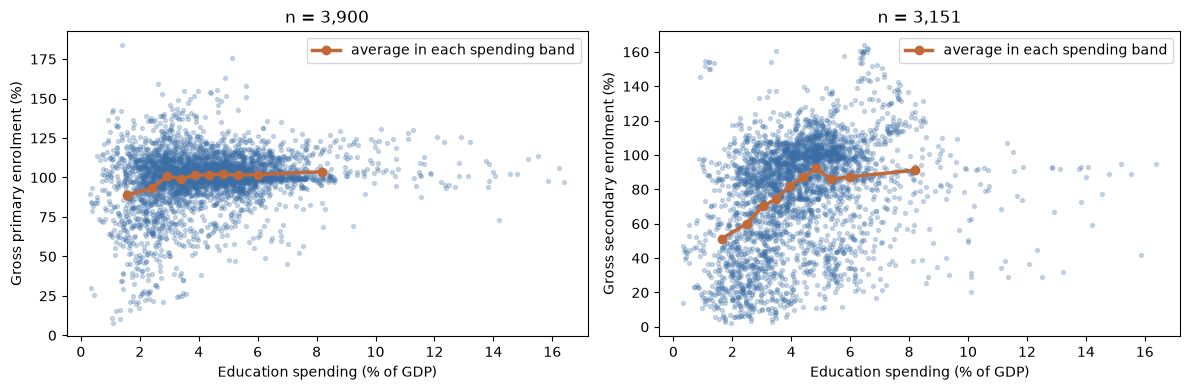

In [2]:
def binned_means(df, x, y, bins=10):
    d = df[[x, y]].dropna()
    d["band"] = pd.qcut(d[x], bins, duplicates="drop")
    g = d.groupby("band", observed=True).agg(x=(x, "mean"), y=(y, "mean"))
    return g

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (y, label) in zip(ax, [("enr_primary_gross", "Gross primary enrolment (%)"),
                              ("enr_secondary_gross", "Gross secondary enrolment (%)")]):
    d = joined[["spend_pct_gdp", y]].dropna()
    a.scatter(d["spend_pct_gdp"], d[y], s=8, alpha=0.25, color="#3b6ea5")
    g = binned_means(joined, "spend_pct_gdp", y)
    a.plot(g["x"], g["y"], color="#c2693a", lw=2.5, marker="o", label="average in each spending band")
    a.set(xlabel="Education spending (% of GDP)", ylabel=label, title=f"n = {len(d):,}")
    a.legend()
plt.tight_layout(); plt.show()

**Draft reading (check against your plot).**
- Primary enrolment is crowded near the top. Many country-years sit at or above 100%, because gross enrolment can pass 100%. That ceiling squeezes the relationship, so I expect a weak correlation for primary even if spending matters.
- Secondary enrolment has far more room to vary, and the relationship looks clearer.
- Both clouds are wide. Spending explains only part of the picture.

## 2. Correlation: Pearson and Spearman

- **Pearson `r`** measures how close the points are to a straight line. It is pulled by extreme values.
- **Spearman `rho`** ranks the values first, so it measures whether *more* spending goes with *more* enrolment even if the pattern is not a straight line. It ignores the ceiling at 100% and the skew in spending better.

I report both. If they disagree a lot, the extreme values are driving Pearson.

`n` is the number of country-years where both columns are present. The `countries` column shows how many different countries those rows come from.

In [3]:
outcomes = {
    "enr_primary_gross":   ("Primary enrolment, gross",   "OWID"),
    "enr_primary_net":     ("Primary enrolment, net",     "WDI"),
    "enr_secondary_gross": ("Secondary enrolment, gross", "WDI"),
    "enr_tertiary_gross":  ("Tertiary enrolment, gross",  "OWID"),
    "dropout_proxy":       ("Dropout proxy (100 - persistence)", "WDI"),
    "out_of_school_share": ("Primary-age children out of school", "OWID"),
}

def corr_row(df, x, y):
    d = df[[x, y, "code"]].dropna()
    r, _ = stats.pearsonr(d[x], d[y])
    rho, _ = stats.spearmanr(d[x], d[y])
    return {"n": len(d), "countries": d["code"].nunique(), "pearson r": round(r, 3), "spearman rho": round(rho, 3)}

rows = {f"{lab} [{src}]": corr_row(joined, "spend_pct_gdp", y) for y, (lab, src) in outcomes.items()}
rows["Primary enrolment, gross, with LAST year's spending"] = corr_row(joined, "spend_lag1", "enr_primary_gross")
raw_table = pd.DataFrame(rows).T
raw_table

,n,countries,pearson r,spearman rho
"Primary enrolment, gross [OWID]",3900.0,203.0,0.197,0.149
"Primary enrolment, net [WDI]",2412.0,180.0,0.264,0.313
"Secondary enrolment, gross [WDI]",3151.0,196.0,0.317,0.381
"Tertiary enrolment, gross [OWID]",3111.0,195.0,0.286,0.347
Dropout proxy (100 - persistence) [WDI],2300.0,178.0,-0.249,-0.306
Primary-age children out of school [OWID],2883.0,198.0,-0.267,-0.293
"Primary enrolment, gross, with LAST year's spending",3876.0,204.0,0.191,0.142


**Draft reading.**
- Every sign points the way the hypothesis says: more spending goes with higher enrolment and with *lower* dropout (negative correlation, because the outcome is a loss).
- The relationships are **weak to moderate**. Primary is the weakest (r about 0.20), secondary and tertiary are stronger (about 0.3), and the dropout and out-of-school measures sit around -0.25.
- Using last year's spending changes almost nothing for primary, so timing is not what limits the relationship.
- Rule of thumb for words: |r| below 0.1 negligible, 0.1 to 0.3 weak, 0.3 to 0.5 moderate, above 0.5 strong.

## 3. Wealth: is it spending or just income?

Rich countries tend to spend a larger share of GDP *and* to enrol more children. If so, the raw correlation partly measures wealth. The **partial correlation** removes the part of each variable that log GDP per capita explains and correlates what is left.

How it works, in three steps (this is the whole method, no library needed):
1. Fit a straight line of spending on log GDP and keep the leftovers (residuals).
2. Do the same for the outcome.
3. Correlate the two sets of leftovers.

Only rows with all three values are used, so `n` is smaller than in section 2. For a fair comparison, the table shows the raw correlation on **the same rows**.

In [4]:
def residuals(y, z):
    slope, intercept = np.polyfit(z, y, 1)
    return y - (slope * z + intercept)

def partial_corr(df, x, y, z, method="pearson"):
    d = df[[x, y, z, "code"]].dropna()
    a, b, c = d[x].to_numpy(), d[y].to_numpy(), d[z].to_numpy()
    if method == "spearman":                      # rank everything first
        a, b, c = stats.rankdata(a), stats.rankdata(b), stats.rankdata(c)
    raw = np.corrcoef(a, b)[0, 1]
    part = np.corrcoef(residuals(a, c), residuals(b, c))[0, 1]
    return len(d), d["code"].nunique(), raw, part

out = {}
for y, (lab, src) in outcomes.items():
    n, nc, raw_p, part_p = partial_corr(joined, "spend_pct_gdp", y, "log_gdp", "pearson")
    _, _, raw_s, part_s = partial_corr(joined, "spend_pct_gdp", y, "log_gdp", "spearman")
    out[f"{lab} [{src}]"] = {"n": n, "countries": nc,
                             "raw r": round(raw_p, 3), "partial r": round(part_p, 3),
                             "raw rho": round(raw_s, 3), "partial rho": round(part_s, 3)}
partial_table = pd.DataFrame(out).T
partial_table

,n,countries,raw r,partial r,raw rho,partial rho
"Primary enrolment, gross [OWID]",3206.0,190.0,0.193,0.176,0.152,0.150
"Primary enrolment, net [WDI]",2043.0,170.0,0.309,0.207,0.350,0.225
"Secondary enrolment, gross [WDI]",2801.0,186.0,0.323,0.344,0.392,0.344
"Tertiary enrolment, gross [OWID]",2580.0,179.0,0.288,0.151,0.373,0.222
Dropout proxy (100 - persistence) [WDI],1986.0,169.0,-0.246,-0.118,-0.321,-0.140
Primary-age children out of school [OWID],2526.0,183.0,-0.258,-0.223,-0.293,-0.204


In [5]:
# how strongly does wealth itself line up with the two variables?
for y in ["spend_pct_gdp", "enr_primary_gross", "enr_secondary_gross"]:
    d = joined[["log_gdp", y]].dropna()
    print(f"log GDP vs {y:22} n={len(d):5,}  r={np.corrcoef(d['log_gdp'], d[y])[0,1]:.3f}")

log GDP vs spend_pct_gdp          n=3,942  r=0.179
log GDP vs enr_primary_gross      n=5,026  r=0.206
log GDP vs enr_secondary_gross    n=4,189  r=0.787


**Draft reading.**
- **Primary:** the partial correlation (about 0.18) is almost the same as the raw one (0.20 on the same rows). Controlling for income barely changes it, so wealth is *not* what produces the small primary correlation.
- **Secondary:** it does not shrink (Pearson 0.32 raw, 0.34 partial). Spending relates to secondary enrolment beyond what income explains, even though income itself is tightly tied to secondary enrolment (r about 0.79).
- **Tertiary and dropout:** these shrink a lot (tertiary roughly halves, dropout roughly halves). A large part of their raw link was wealth.
- Spending as a share of GDP and log GDP are only weakly related (r about 0.18). That is why controlling for income changes things less than you might expect.
- Honest wording: *a positive, weak association that survives a control for income, strongest for secondary.* It is not evidence that spending causes enrolment.

## 4. Inside each income group

Another way to hold income fixed: compare only countries in the same World Bank income group. This also shows whether the overall pattern is the same everywhere or hides different stories.

In [6]:
order = ["Low", "Lower middle", "Upper middle", "High"]
rows = {}
for g in order:
    sub = joined[joined["income_group"] == g]
    for y, lab in [("enr_primary_gross", "primary"), ("enr_secondary_gross", "secondary")]:
        c = corr_row(sub, "spend_pct_gdp", y)
        rows[(g, lab)] = c
by_group = pd.DataFrame(rows).T
by_group.index.names = ["income group", "outcome"]
by_group

n  countries  pearson r  spearman rho
income group outcome                                             
Low          primary    683.0       65.0      0.218         0.254
             secondary  511.0       59.0      0.206         0.273
Lower middle primary    907.0       92.0      0.156         0.104
             secondary  749.0       88.0      0.228         0.265
Upper middle primary    828.0       78.0      0.269         0.280
             secondary  764.0       75.0      0.201         0.290
High         primary    927.0       73.0     -0.111        -0.071
             secondary  907.0       73.0      0.369         0.393

**Draft reading.**
- For **primary** enrolment, the relationship is clearly positive in the Low and Upper-middle groups (r about 0.22 and 0.27) and weaker in Lower middle.
- In the **High** income group it is slightly **negative** (r about -0.11). Almost every rich country is already near full enrolment, so extra spending cannot raise it. That is the ceiling effect again, not evidence that spending hurts.
- For **secondary** enrolment the relationship is positive in every group, including High income (r about 0.37), because secondary enrolment still has room to rise there.
- So the overall number mixes different stories. Say this in the article: the average hides that spending matters most where enrolment is still low.

## 5. A probability you can say out loud

Define (from the join notebook):
- `high_spend` = spending above the median of the country's income group (so rich and poor countries are each judged against peers)
- `high_enrol_primary` = gross primary enrolment of at least 90%

Then compare two conditional probabilities:

$$P(\text{high enrolment} \mid \text{high spending}) \quad\text{versus}\quad P(\text{high enrolment} \mid \text{low spending})$$

If spending is unrelated to enrolment, the two would be equal. The brief's "more than one source" rule is met because `high_spend` combines OWID spending with the World Bank income classification, and the outcome comes from OWID.

In [7]:
d = joined.dropna(subset=["high_spend", "high_enrol_primary"]).copy()
d["high_spend"] = d["high_spend"].astype(int)
d["high_enrol_primary"] = d["high_enrol_primary"].astype(int)

counts = pd.crosstab(d["high_spend"], d["high_enrol_primary"])
counts.index = ["low spending", "high spending"]
counts.columns = ["enrolment < 90%", "enrolment >= 90%"]
display(counts)

p_high = d.loc[d["high_spend"] == 1, "high_enrol_primary"].mean()
p_low = d.loc[d["high_spend"] == 0, "high_enrol_primary"].mean()
print(f"P(high enrolment | high spending) = {p_high:.3f}")
print(f"P(high enrolment | low spending)  = {p_low:.3f}")
print(f"difference                        = {p_high - p_low:+.3f}  ({(p_high - p_low) * 100:.1f} percentage points)")
print(f"ratio                             = {p_high / p_low:.2f}")
print(f"rows used: {len(d):,}  countries: {d['code'].nunique()}")

,enrolment < 90%,enrolment >= 90%
low spending,291,1342
high spending,168,1544


P(high enrolment | high spending) = 0.902
P(high enrolment | low spending)  = 0.822
difference                        = +0.080  (8.0 percentage points)
ratio                             = 1.10
rows used: 3,345  countries: 199


In [8]:
# does the gap hold inside each income group? (it should not be an artefact of mixing groups)
g = (d.groupby(["income_group", "high_spend"])["high_enrol_primary"].agg(["mean", "count"]).round(3)
       .unstack("high_spend"))
g.columns = [f"{'high' if h == 1 else 'low'} spending: {s}" for s, h in g.columns]
g = g.loc[order]
g["gap (pp)"] = ((g["high spending: mean"] - g["low spending: mean"]) * 100).round(1)
g

,low spending: mean,high spending: mean,low spending: count,high spending: count,gap (pp)
income_group,,,,,
Low,0.467,0.703,323,360,23.6
Lower middle,0.868,0.894,455,452,2.6
Upper middle,0.922,0.995,411,417,7.3
High,0.939,0.977,444,483,3.8


**Draft reading.**
- Overall, about 90% of high-spending country-years have primary enrolment of at least 90%, against about 82% of low-spending ones: a gap of roughly 8 percentage points.
- The gap is biggest in the **Low** income group (about 70% against 47%, more than 20 points) and small where nearly everyone is already enrolled (High income: about 98% against 94%).
- This is a comparison of two naturally occurring groups, not an experiment. Countries were not assigned to high or low spending, so other differences (stability, geography, aid) may explain the gap. Phase 5 turns this into a formal test.

## 6. Robustness: the same country appears in many years

Every row is one country in one year, and a country's values barely change from year to year. So 3,000 rows are really about 200 countries observed repeatedly. The correlation itself is still a fair description of the data, but any uncertainty calculated as if the rows were independent is **too optimistic**.

Two checks:
1. **Country averages.** Average each country over all its years (one row per country) and correlate those.
2. **Cluster bootstrap.** Resample whole *countries* with replacement, recompute the headline partial correlation each time, and read the spread. This gives an honest interval.

In [9]:
ca = (joined.groupby("code")[["spend_pct_gdp", "enr_primary_gross", "log_gdp"]].mean().dropna())
r_c, _ = stats.pearsonr(ca["spend_pct_gdp"], ca["enr_primary_gross"])
rho_c, _ = stats.spearmanr(ca["spend_pct_gdp"], ca["enr_primary_gross"])
print(f"country averages: n = {len(ca)} countries, Pearson r = {r_c:.3f}, Spearman rho = {rho_c:.3f}")

country averages: n = 193 countries, Pearson r = 0.380, Spearman rho = 0.318


In [10]:
rng = np.random.default_rng(42)
dd = joined[["code", "spend_pct_gdp", "enr_primary_gross", "log_gdp"]].dropna().reset_index(drop=True)
idx_by_country = [g.index.to_numpy() for _, g in dd.groupby("code")]
X, Y, Z = dd["spend_pct_gdp"].to_numpy(), dd["enr_primary_gross"].to_numpy(), dd["log_gdp"].to_numpy()

def partial_r(ix):
    x, y, z = X[ix], Y[ix], Z[ix]
    return np.corrcoef(residuals(x, z), residuals(y, z))[0, 1]

point = partial_r(np.arange(len(dd)))
boot = []
for _ in range(2000):
    pick = rng.integers(0, len(idx_by_country), len(idx_by_country))
    boot.append(partial_r(np.concatenate([idx_by_country[i] for i in pick])))
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"HEADLINE: partial r (spending vs primary enrolment | log GDP) = {point:.3f}")
print(f"95% interval resampling countries: [{lo:.3f}, {hi:.3f}]   (n = {len(dd):,} rows, {len(idx_by_country)} countries)")

HEADLINE: partial r (spending vs primary enrolment | log GDP) = 0.176
95% interval resampling countries: [0.084, 0.271]   (n = 3,206 rows, 190 countries)


**Draft reading.**
- Country averages give a *larger* correlation (about 0.38): averaging removes year-to-year noise. The relationship is not an artefact of repeated rows.
- The country-level bootstrap interval for the headline partial correlation is wide but stays above zero (about 0.08 to 0.27 in my run). Read it as: *probably a small positive association*, not a precise number.